In [1]:
# Cell 1: Imports and Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("All imports successful ✓")

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
2026-05-09 11:33:46.004549: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778326426.198460      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778326426.254071      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778326426.714572      57 computation_placer.cc:177] computation placer already registered. Please check linkage a

TensorFlow version: 2.19.0
All imports successful ✓


In [2]:
# Cell 2: Load and Explore Dataset
df = pd.read_csv('/kaggle/input/datasets/chrysosdhonju/financial-phrase/3. Financial Phrase Dataset/financial_phrase.csv', 
                 encoding='latin-1')

# Preview
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df.iloc[:, 1].value_counts())

Shape: (2264, 2)

First 5 rows:


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive



Column names: ['text', 'label']

Data types:
 text     object
label    object
dtype: object

Missing values:
 text     0
label    0
dtype: int64

Class distribution:
 label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


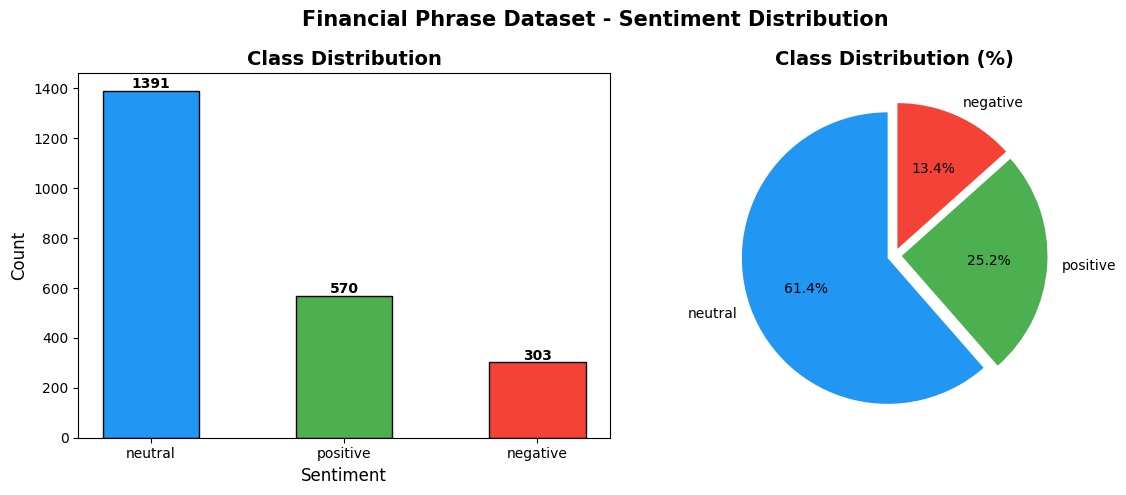


Dataset is IMBALANCED:
  Neutral:  1391 (61.4%)
  Positive: 570 (25.2%)
  Negative: 303 (13.4%)


In [4]:
# Cell 3: Visualize Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
colors = ['#2196F3', '#4CAF50', '#F44336']
label_counts = df['label'].value_counts()

axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for i, (label, count) in enumerate(label_counts.items()):
    axes[0].text(i, count + 10, str(count), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, 
            labels=label_counts.index, 
            autopct='%1.1f%%', 
            colors=colors,
            startangle=90,
            explode=(0.05, 0.05, 0.05))
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Financial Phrase Dataset - Sentiment Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDataset is IMBALANCED:")
print(f"  Neutral:  {label_counts['neutral']} ({label_counts['neutral']/len(df)*100:.1f}%)")
print(f"  Positive: {label_counts['positive']} ({label_counts['positive']/len(df)*100:.1f}%)")
print(f"  Negative: {label_counts['negative']} ({label_counts['negative']/len(df)*100:.1f}%)")

In [5]:
# Cell 4: Text Cleaning and Preprocessing
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Keep financial sentiment-important words
keep_words = {'no', 'not', 'nor', 'neither', 'never', 'none', 
              'up', 'down', 'above', 'below', 'against', 'loss', 'profit'}
stop_words = stop_words - keep_words

def clean_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Handle contractions
    contractions = {
        "don't": "do not", "won't": "will not", "can't": "cannot",
        "isn't": "is not", "aren't": "are not", "wasn't": "was not",
        "weren't": "were not", "hasn't": "has not", "haven't": "have not",
        "didn't": "did not", "doesn't": "does not", "wouldn't": "would not",
        "shouldn't": "should not", "couldn't": "could not"
    }
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)
    
    # Remove currency symbols and financial abbreviations patterns
    # e.g. EUR131m, EUR0.9m -> keep the word context but remove the number
    text = re.sub(r'eur\s?\d+\.?\d*\s?[mb]?', 'currency_amount', text)
    text = re.sub(r'usd\s?\d+\.?\d*\s?[mb]?', 'currency_amount', text)
    
    # Remove percentages (keep the word around it)
    text = re.sub(r'\d+\.?\d*\s?%', 'percentage_value', text)
    
    # Remove remaining numbers
    text = re.sub(r'\b\d+\.?\d*\b', '', text)
    
    # Remove special characters but keep spaces
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize
    tokens = text.split()
    
    # Remove stopwords and lemmatize, keep words longer than 1 char
    tokens = [lemmatizer.lemmatize(word) for word in tokens 
              if word not in stop_words and len(word) > 1]
    
    return ' '.join(tokens)

# Apply cleaning
df['cleaned_text'] = df['text'].apply(clean_text)

# Preview results
print("=== Sample Cleaning Results ===\n")
for i in range(5):
    print(f"[{df['label'].iloc[i].upper()}]")
    print(f"  ORIGINAL : {df['text'].iloc[i][:100]}")
    print(f"  CLEANED  : {df['cleaned_text'].iloc[i][:100]}")
    print()

# Text length after cleaning
df['text_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))
print("=== Cleaned Text Length Stats per Sentiment ===")
print(df.groupby('label')['text_length'].describe().round(2))

print(f"\nRecommended padding length (95th percentile): {int(np.percentile(df['text_length'], 95))}")

=== Sample Cleaning Results ===

[NEUTRAL]
  ORIGINAL : According to Gran , the company has no plans to move all production to Russia , although that is whe
  CLEANED  : according gran company no plan move production russia although company growing

[POSITIVE]
  ORIGINAL : For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same p
  CLEANED  : last quarter componenta net sale doubled currency_amount currency_amount period year earlier moved z

[POSITIVE]
  ORIGINAL : In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit b
  CLEANED  : third quarter net sale increased percentage_value currency_amountn operating profit percentage_value

[POSITIVE]
  ORIGINAL : Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representin
  CLEANED  : operating profit rose currency_amountn currency_amountn corresponding period representing percentage

[POSITIVE]
  ORIGINAL : Operat

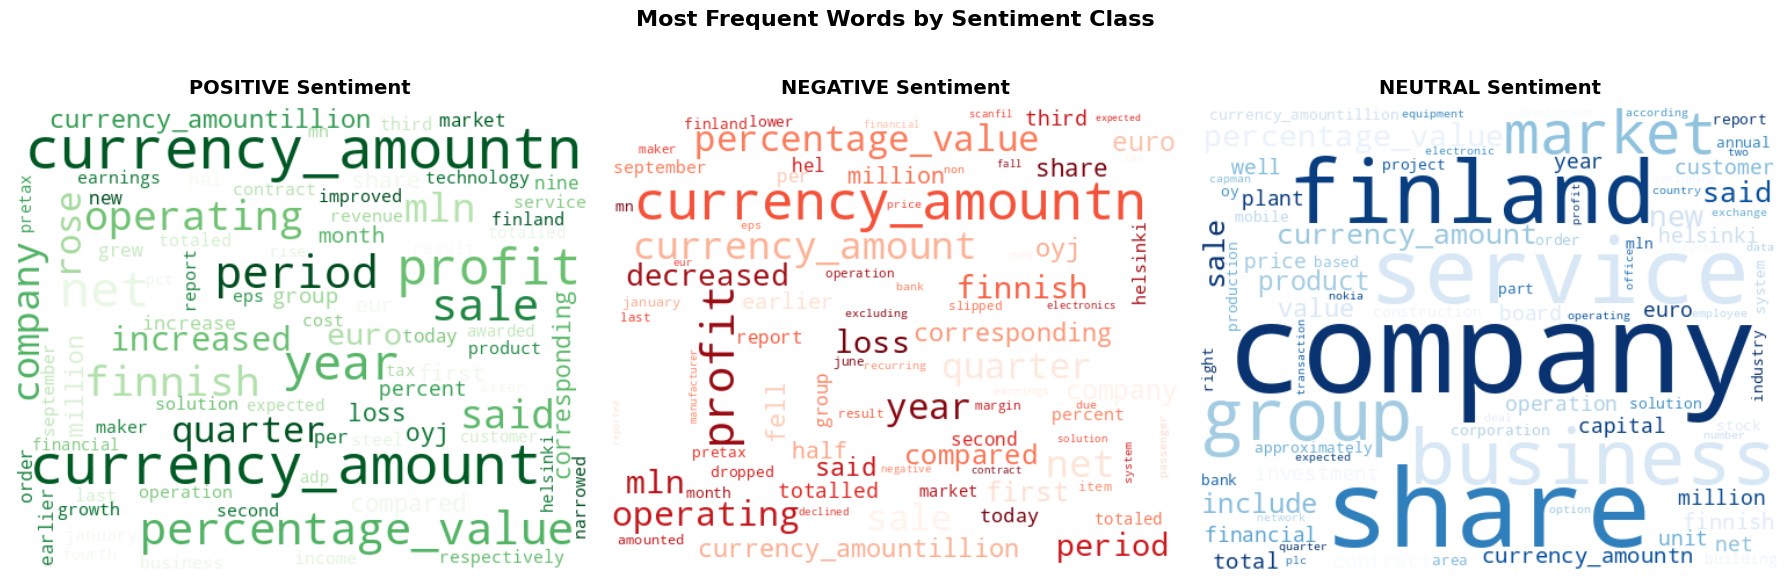

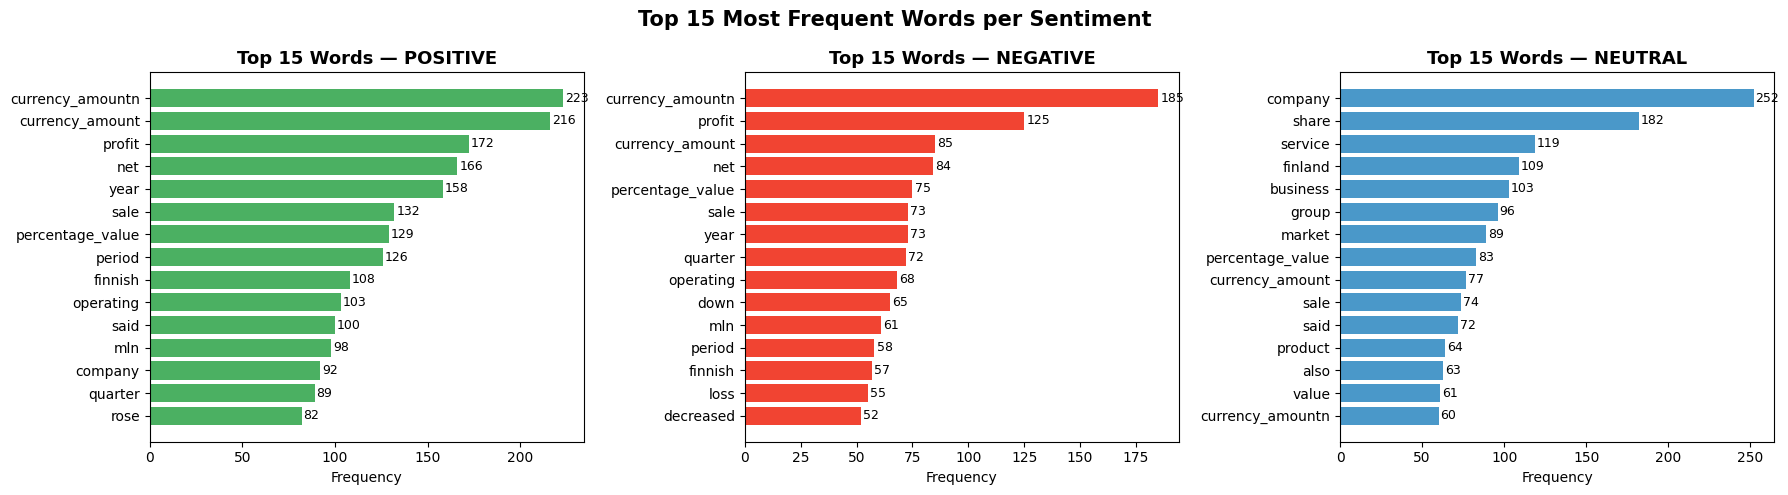

All visualizations saved ✓


In [6]:
# Cell 5: WordCloud and Top Words Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sentiments = ['positive', 'negative', 'neutral']
colors_map = {'positive': 'Greens', 'negative': 'Reds', 'neutral': 'Blues'}

for ax, sentiment in zip(axes, sentiments):
    text_blob = ' '.join(df[df['label'] == sentiment]['cleaned_text'].tolist())
    
    wordcloud = WordCloud(
        width=500,
        height=400,
        background_color='white',
        colormap=colors_map[sentiment],
        max_words=80,
        collocations=False
    ).generate(text_blob)
    
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment.upper()} Sentiment', 
                 fontsize=14, fontweight='bold', pad=10)

plt.suptitle('Most Frequent Words by Sentiment Class', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 15 words bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sentiment in zip(axes, sentiments):
    text_blob = ' '.join(df[df['label'] == sentiment]['cleaned_text'].tolist())
    
    # Count word frequencies
    all_words = text_blob.split()
    word_counts = {}
    for word in all_words:
        word_counts[word] = word_counts.get(word, 0) + 1
    
    # Sort and take top 15
    top_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:15]
    words = [w[0] for w in top_words][::-1]
    counts = [w[1] for w in top_words][::-1]
    
    cmap = plt.cm.get_cmap(colors_map[sentiment])
    bars = ax.barh(words, counts, color=cmap(0.6))
    ax.set_title(f'Top 15 Words — {sentiment.upper()}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')
    
    for bar, val in zip(bars, counts):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)

plt.suptitle('Top 15 Most Frequent Words per Sentiment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/top_words.png', dpi=150, bbox_inches='tight')
plt.show()

print("All visualizations saved ✓")

In [7]:
# Cell 6: Label Encoding, Tokenization, Padding and Train/Val/Test Split

# ── 1. Encode labels ──────────────────────────────────────────────
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

print("Label Encoding Mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

# ── 2. Train / Val / Test Split (70 / 15 / 15) ───────────────────
X = df['cleaned_text'].values
y = df['label_encoded'].values

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

# Second split: 50% of temp → val, 50% → test (i.e 15/15)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"\nDataset Split:")
print(f"  Train : {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Val   : {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test  : {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

# Verify stratification
print(f"\nClass distribution in splits:")
for split_name, split_y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    unique, counts = np.unique(split_y, return_counts=True)
    print(f"  {split_name}: ", {le.classes_[u]: c for u, c in zip(unique, counts)})

# ── 3. Tokenization ───────────────────────────────────────────────
MAX_WORDS = 5000  # vocabulary size

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)  # fit only on training data

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print(f"\nVocabulary size     : {len(tokenizer.word_index)}")
print(f"Capped vocab size   : {vocab_size}")

# ── 4. Padding ────────────────────────────────────────────────────
MAX_LEN = 30  # slightly above 95th percentile (23) for financial sentences

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nPadding length (MAX_LEN): {MAX_LEN}")
print(f"X_train_pad shape : {X_train_pad.shape}")
print(f"X_val_pad shape   : {X_val_pad.shape}")
print(f"X_test_pad shape  : {X_test_pad.shape}")

# ── 5. One-hot encode labels for categorical crossentropy ─────────
from tensorflow.keras.utils import to_categorical
NUM_CLASSES = 3

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print(f"\ny_train_cat shape : {y_train_cat.shape}")
print("\nTokenization and Padding complete ✓")

Label Encoding Mapping:
  negative → 0
  neutral → 1
  positive → 2

Dataset Split:
  Train : 1584 samples (70.0%)
  Val   : 340 samples (15.0%)
  Test  : 340 samples (15.0%)

Class distribution in splits:
  Train:  {'negative': np.int64(212), 'neutral': np.int64(973), 'positive': np.int64(399)}
  Val:  {'negative': np.int64(45), 'neutral': np.int64(209), 'positive': np.int64(86)}
  Test:  {'negative': np.int64(46), 'neutral': np.int64(209), 'positive': np.int64(85)}

Vocabulary size     : 4089
Capped vocab size   : 4090

Padding length (MAX_LEN): 30
X_train_pad shape : (1584, 30)
X_val_pad shape   : (340, 30)
X_test_pad shape  : (340, 30)

y_train_cat shape : (1584, 3)

Tokenization and Padding complete ✓


I0000 00:00:1778326561.275185      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...


Training Model 1 - Simple RNN...
Epoch 1/30


I0000 00:00:1778326563.217982     133 service.cc:152] XLA service 0x7c810c0050e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778326563.218035     133 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778326563.689502     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


36/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5766 - loss: 0.9583

I0000 00:00:1778326565.355419     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.6038 - loss: 0.9168 - val_accuracy: 0.6765 - val_loss: 0.7903
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7715 - loss: 0.6093 - val_accuracy: 0.6118 - val_loss: 0.9748
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8257 - loss: 0.4344 - val_accuracy: 0.7294 - val_loss: 0.6980
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8451 - loss: 0.3666 - val_accuracy: 0.7412 - val_loss: 0.6597
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8819 - loss: 0.2704 - val_accuracy: 0.6676 - val_loss: 0.8209
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9472 - loss: 0.1651 - val_accuracy: 0.7235 - val_loss: 0.9046
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9679 - loss: 0.1028 - val_accuracy: 0.7471 - val_loss: 0.9034
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9877 - loss: 0.0455 - val_accuracy: 0.7559 - val_loss: 0.8979
Ep

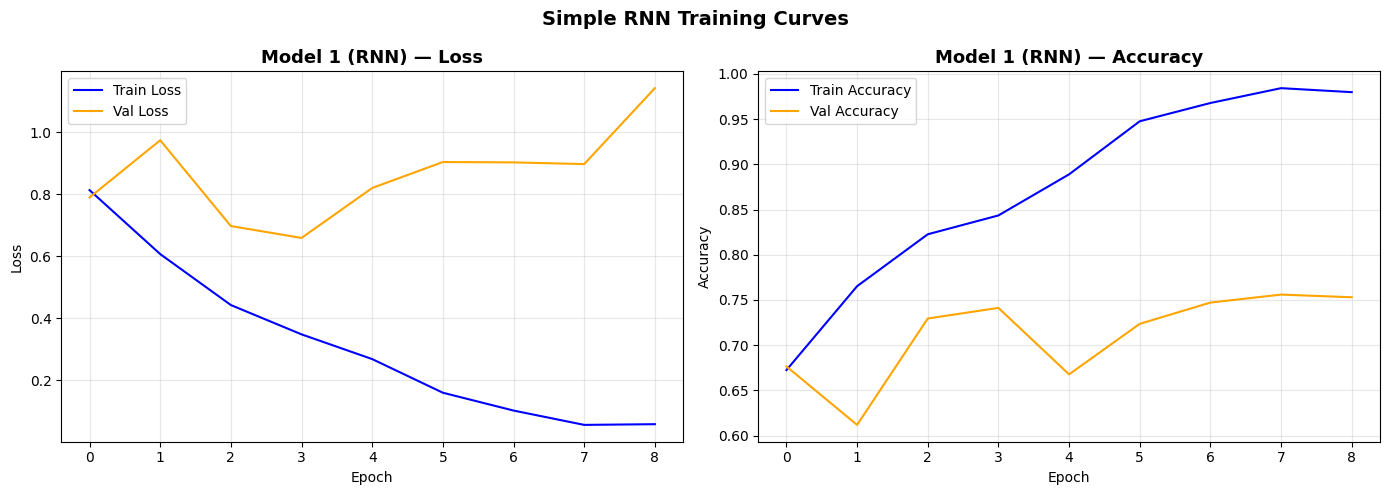

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step

=== Model 1 (Simple RNN) — Test Set Evaluation ===
Accuracy: 75.88%

Classification Report:
              precision    recall  f1-score   support

    negative       0.48      0.35      0.41        46
     neutral       0.91      0.85      0.88       209
    positive       0.58      0.75      0.65        85

    accuracy                           0.76       340
   macro avg       0.66      0.65      0.65       340
weighted avg       0.77      0.76      0.76       340



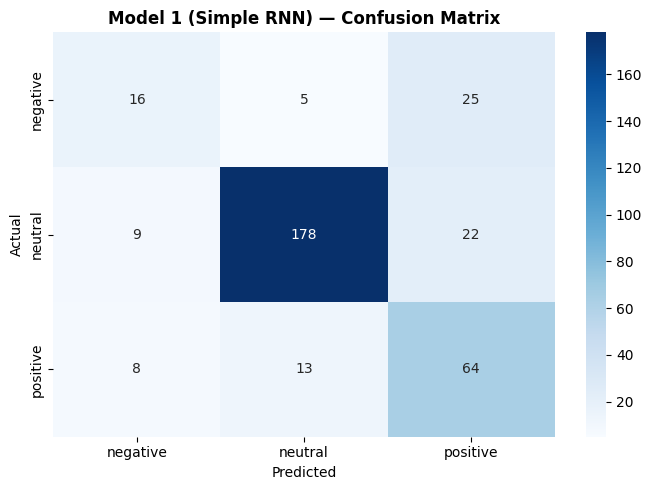

In [9]:
# Cell 7: Model 1 - Simple RNN with Trainable Embedding

EMBED_DIM = 64
RNN_UNITS = 64

model1 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SimpleRNN(RNN_UNITS, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name='Simple_RNN')

model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model1.summary()

# ── Training ──────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

print("\nTraining Model 1 - Simple RNN...")
history1 = model1.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ── Plot Training Curves ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history1.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history1.history['val_loss'], label='Val Loss', color='orange')
axes[0].set_title('Model 1 (RNN) — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history1.history['accuracy'], label='Train Accuracy', color='blue')
axes[1].plot(history1.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[1].set_title('Model 1 (RNN) — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Simple RNN Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/model1_rnn_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Evaluation ────────────────────────────────────────────────────
y_pred1 = np.argmax(model1.predict(X_test_pad), axis=1)

print("\n=== Model 1 (Simple RNN) — Test Set Evaluation ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred1)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred1, target_names=le.classes_))

# Confusion Matrix
cm1 = confusion_matrix(y_test, y_pred1)
plt.figure(figsize=(7, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Model 1 (Simple RNN) — Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('/kaggle/working/model1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training Model 2 - LSTM...
Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5868 - loss: 0.9934 - val_accuracy: 0.6235 - val_loss: 0.8361
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6987 - loss: 0.7143 - val_accuracy: 0.7735 - val_loss: 0.5765
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8087 - loss: 0.4797 - val_accuracy: 0.7471 - val_loss: 0.6121
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8394 - loss: 0.3806 - val_accuracy: 0.7647 - val_loss: 0.5357
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8374 - loss: 0.3332 - val_accuracy: 0.7559 - val_loss: 0.6542
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8497 - loss: 0.3037 - val_accuracy: 0.7647 - val_loss: 0.5968
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8593 - loss: 0.2829 - val_accuracy: 0.7647 - val_loss: 0.6786
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8625 - loss: 0.267

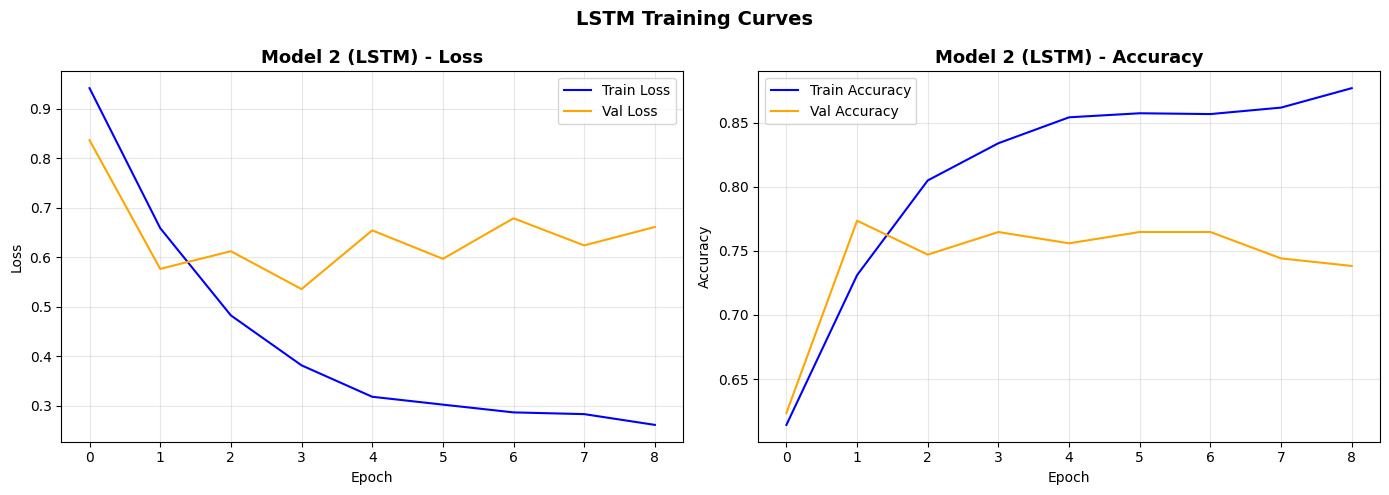

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

=== Model 2 (LSTM) - Test Set Evaluation ===
Accuracy: 76.18%

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        46
     neutral       0.90      0.90      0.90       209
    positive       0.53      0.82      0.65        85

    accuracy                           0.76       340
   macro avg       0.48      0.58      0.52       340
weighted avg       0.69      0.76      0.72       340



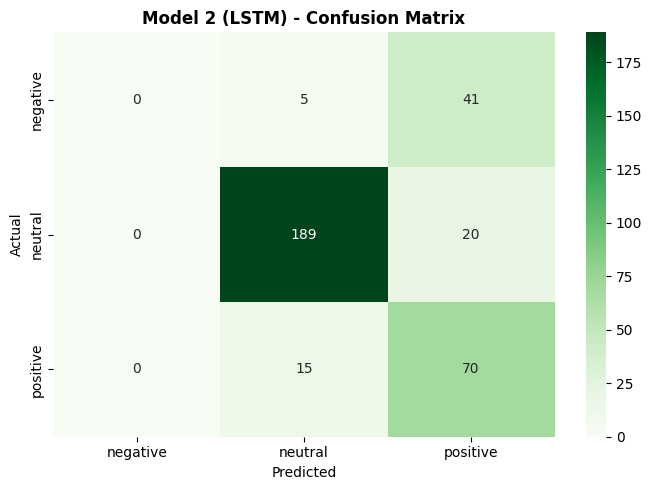

In [10]:
# Cell 8: Model 2 - LSTM with Trainable Embedding

model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=MAX_LEN),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name='LSTM_Trainable_Embedding')

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

# Training
early_stop2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("\nTraining Model 2 - LSTM...")
history2 = model2.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop2],
    verbose=1
)

# Plot Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history2.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history2.history['val_loss'], label='Val Loss', color='orange')
axes[0].set_title('Model 2 (LSTM) - Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history2.history['accuracy'], label='Train Accuracy', color='blue')
axes[1].plot(history2.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[1].set_title('Model 2 (LSTM) - Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LSTM Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/model2_lstm_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluation
y_pred2 = np.argmax(model2.predict(X_test_pad), axis=1)

print("\n=== Model 2 (LSTM) - Test Set Evaluation ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred2)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred2, target_names=le.classes_))

# Confusion Matrix
cm2 = confusion_matrix(y_test, y_pred2)
plt.figure(figsize=(7, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Model 2 (LSTM) - Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('/kaggle/working/model2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Cell 9: Install gensim (Kaggle compatible)
!pip install gensim -q

In [13]:
# Cell 9b: Load GloVe Embeddings and Build Model 3

import gensim.downloader as api

print("Downloading GloVe embeddings... (this may take 2-3 minutes)")
glove_model = api.load('glove-wiki-gigaword-50')
print("GloVe embeddings loaded successfully ✓")
print(f"Vocabulary size in GloVe: {len(glove_model)}")

# Build embedding matrix
EMBED_DIM_GLOVE = 50
embedding_matrix = np.zeros((vocab_size, EMBED_DIM_GLOVE))

found = 0
not_found = 0
for word, idx in tokenizer.word_index.items():
    if idx < vocab_size:
        if word in glove_model:
            embedding_matrix[idx] = glove_model[word]
            found += 1
        else:
            not_found += 1

print(f"\nWords found in GloVe    : {found}")
print(f"Words not found in GloVe: {not_found}")
print(f"Coverage                : {found/(found+not_found)*100:.1f}%")
print(f"Embedding matrix shape  : {embedding_matrix.shape}")

GloVe embeddings loaded successfully ✓
Vocabulary size in GloVe: 400000

Words found in GloVe    : 3626
Words not found in GloVe: 463
Coverage                : 88.7%
Embedding matrix shape  : (4090, 50)


Class Weights: {0: np.float64(2.490566037735849), 1: np.float64(0.5426515930113053), 2: np.float64(1.3233082706766917)}


Model: "LSTM_GloVe_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       204,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,500 (798.83 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 204,500 (798.83 KB)


Training Model 3 - LSTM with GloVe...
Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.3190 - loss: 1.0394 - val_accuracy: 0.6647 - val_loss: 0.8306
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6871 - loss: 0.8129 - val_accuracy: 0.6765 - val_loss: 0.6711
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7041 - loss: 0.7173 - val_accuracy: 0.6882 - val_loss: 0.6556
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7192 - loss: 0.6977 - val_accuracy: 0.7265 - val_loss: 0.5519
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7382 - loss: 0.6615 - val_accuracy: 0.7147 - val_loss: 0.5789
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7252 - loss: 0.6507 - val_accuracy: 0.6912 - val_loss: 0.6032
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7236 - loss: 0.6710 - val_accuracy: 0.7559 - val_loss: 0.5512
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7630 - 

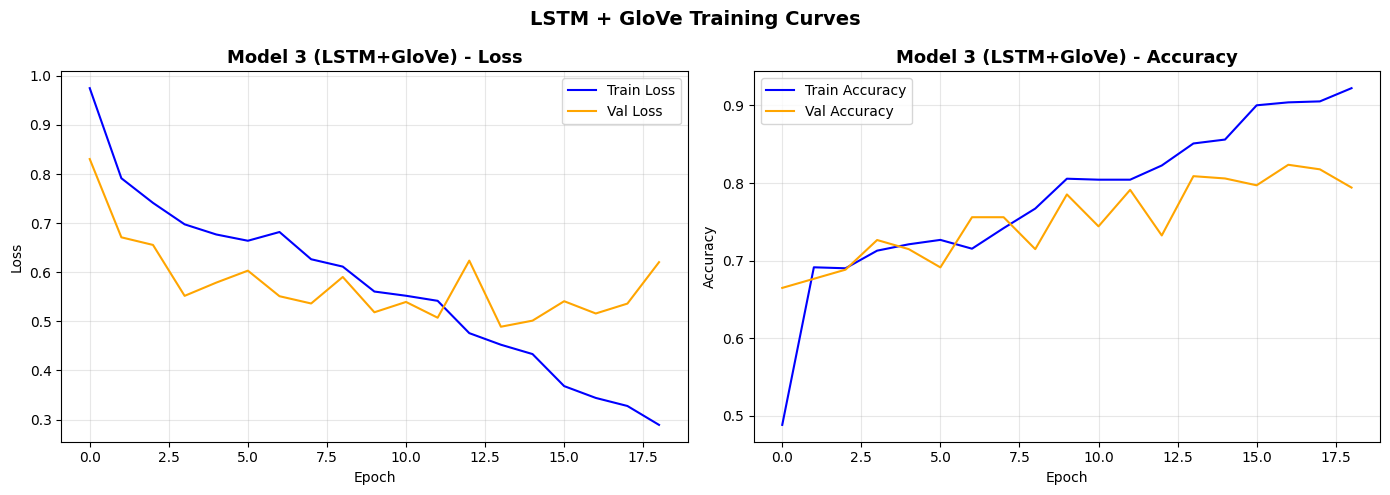

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

=== Model 3 (LSTM + GloVe) - Test Set Evaluation ===
Accuracy: 78.24%

Classification Report:
              precision    recall  f1-score   support

    negative       0.66      0.80      0.73        46
     neutral       0.90      0.85      0.87       209
    positive       0.60      0.61      0.60        85

    accuracy                           0.78       340
   macro avg       0.72      0.75      0.73       340
weighted avg       0.79      0.78      0.79       340



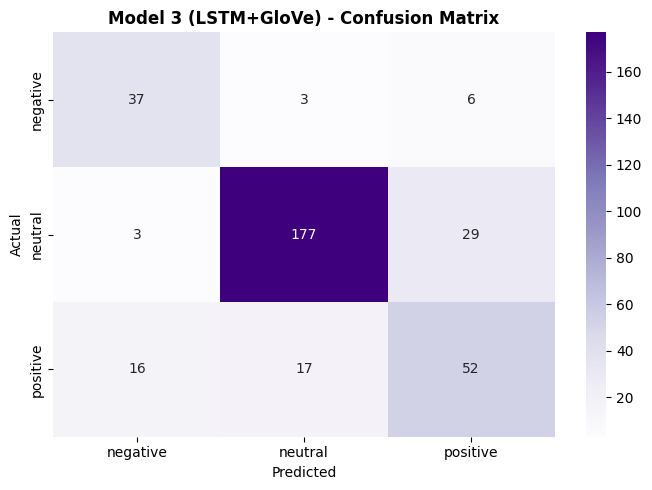

In [14]:
# Cell 9c: Model 3 - LSTM with Pretrained GloVe Embeddings

# Handle class imbalance with class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)

# Build Model 3
model3 = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBED_DIM_GLOVE,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False  # Freeze GloVe weights
    ),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name='LSTM_GloVe_Embedding')

model3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model3.summary()

# Training
early_stop3 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("\nTraining Model 3 - LSTM with GloVe...")
history3 = model3.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop3],
    class_weight=class_weight_dict,
    verbose=1
)

# Plot Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history3.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history3.history['val_loss'], label='Val Loss', color='orange')
axes[0].set_title('Model 3 (LSTM+GloVe) - Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history3.history['accuracy'], label='Train Accuracy', color='blue')
axes[1].plot(history3.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[1].set_title('Model 3 (LSTM+GloVe) - Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LSTM + GloVe Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/model3_glove_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluation
y_pred3 = np.argmax(model3.predict(X_test_pad), axis=1)

print("\n=== Model 3 (LSTM + GloVe) - Test Set Evaluation ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred3)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred3, target_names=le.classes_))

# Confusion Matrix
cm3 = confusion_matrix(y_test, y_pred3)
plt.figure(figsize=(7, 5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Model 3 (LSTM+GloVe) - Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('/kaggle/working/model3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

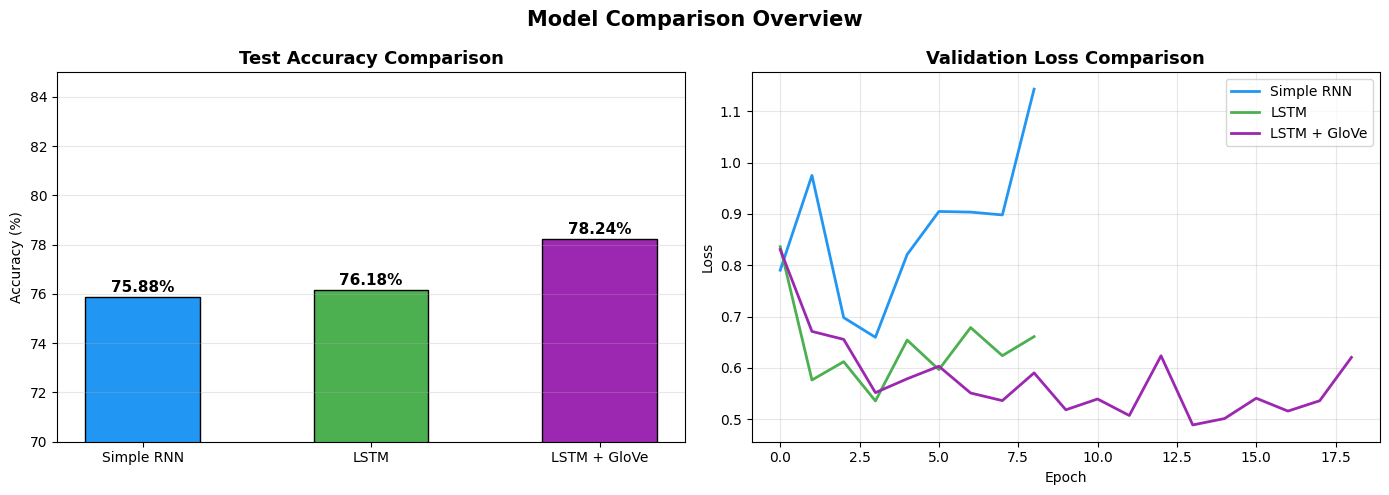

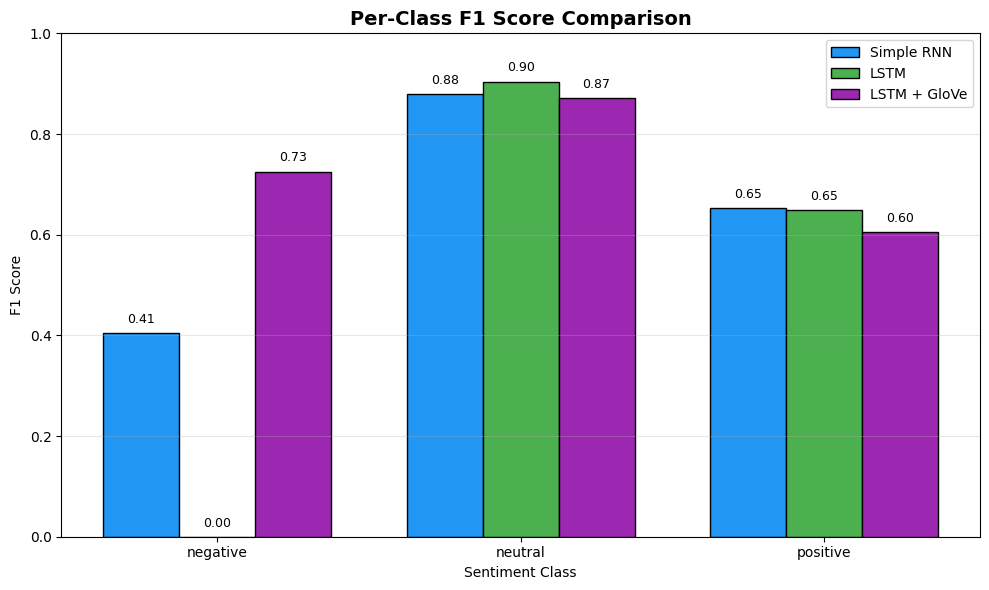

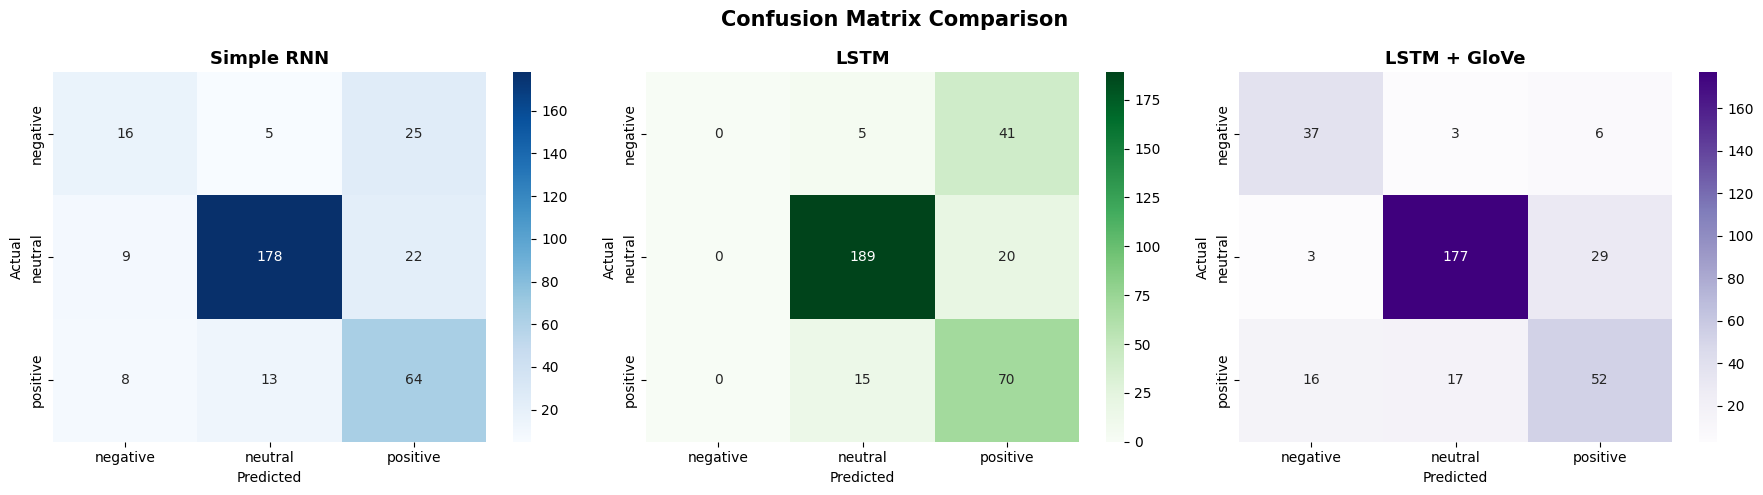


         FINAL MODEL COMPARISON SUMMARY
Model                  Accuracy   Macro F1   Neg Recall
------------------------------------------------------------
Simple RNN               75.88%      0.646        0.348
LSTM                     76.18%      0.517        0.000
LSTM+GloVe               78.24%      0.734        0.804


In [15]:
# Cell 10: All 3 Models Comparison

# ── 1. Accuracy Comparison Bar Chart ─────────────────────────────
models = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
accuracies = [
    accuracy_score(y_test, y_pred1) * 100,
    accuracy_score(y_test, y_pred2) * 100,
    accuracy_score(y_test, y_pred3) * 100
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(models, accuracies, color=['#2196F3', '#4CAF50', '#9C27B0'],
                   edgecolor='black', width=0.5)
axes[0].set_title('Test Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(70, 85)
axes[0].grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=11)

# ── 2. Training Loss Curves All Models ───────────────────────────
axes[1].plot(history1.history['val_loss'], label='Simple RNN', color='#2196F3', linewidth=2)
axes[1].plot(history2.history['val_loss'], label='LSTM', color='#4CAF50', linewidth=2)
axes[1].plot(history3.history['val_loss'], label='LSTM + GloVe', color='#9C27B0', linewidth=2)
axes[1].set_title('Validation Loss Comparison', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Comparison Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. Per Class F1 Score Comparison ─────────────────────────────
from sklearn.metrics import f1_score

classes = le.classes_
f1_rnn  = f1_score(y_test, y_pred1, average=None)
f1_lstm = f1_score(y_test, y_pred2, average=None)
f1_glove= f1_score(y_test, y_pred3, average=None)

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, f1_rnn,  width, label='Simple RNN',   color='#2196F3', edgecolor='black')
ax.bar(x,         f1_lstm, width, label='LSTM',          color='#4CAF50', edgecolor='black')
ax.bar(x + width, f1_glove,width, label='LSTM + GloVe', color='#9C27B0', edgecolor='black')

ax.set_title('Per-Class F1 Score Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment Class')
ax.set_ylabel('F1 Score')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.0)

for i, (r, l, g) in enumerate(zip(f1_rnn, f1_lstm, f1_glove)):
    ax.text(i - width, r + 0.02, f'{r:.2f}', ha='center', fontsize=9)
    ax.text(i,         l + 0.02, f'{l:.2f}', ha='center', fontsize=9)
    ax.text(i + width, g + 0.02, f'{g:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Side by Side Confusion Matrices ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title, cmap in zip(
    axes,
    [cm1, cm2, cm3],
    ['Simple RNN', 'LSTM', 'LSTM + GloVe'],
    ['Blues', 'Greens', 'Purples']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(f'{title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. Summary Table ─────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score

print("\n" + "="*60)
print("         FINAL MODEL COMPARISON SUMMARY")
print("="*60)
print(f"{'Model':<20} {'Accuracy':>10} {'Macro F1':>10} {'Neg Recall':>12}")
print("-"*60)
for name, y_pred in [('Simple RNN', y_pred1), ('LSTM', y_pred2), ('LSTM+GloVe', y_pred3)]:
    acc = accuracy_score(y_test, y_pred) * 100
    f1  = f1_score(y_test, y_pred, average='macro')
    neg_recall = recall_score(y_test, y_pred, average=None)[0]
    print(f"{name:<20} {acc:>9.2f}% {f1:>10.3f} {neg_recall:>12.3f}")
print("="*60)

In [17]:
# Cell 11: Error Analysis

# Use best model (Model 3 - LSTM + GloVe)
print("=== ERROR ANALYSIS - Model 3 (LSTM + GloVe) ===\n")

# Get misclassified samples
test_df = pd.DataFrame({
    'original_text': df['text'].iloc[
        df.index[df['cleaned_text'].isin(
            pd.Series(X_test)
        )]
    ].values if False else X_test,
    'cleaned_text': X_test,
    'true_label': le.inverse_transform(y_test),
    'pred_label': le.inverse_transform(y_pred3)
})

# Find misclassified
misclassified = test_df[test_df['true_label'] != test_df['pred_label']].reset_index(drop=True)

print(f"Total test samples     : {len(test_df)}")
print(f"Correctly classified   : {len(test_df) - len(misclassified)}")
print(f"Misclassified          : {len(misclassified)}")
print(f"Error Rate             : {len(misclassified)/len(test_df)*100:.2f}%\n")

# Misclassification breakdown
print("=== Misclassification Breakdown ===")
error_breakdown = misclassified.groupby(['true_label', 'pred_label']).size().reset_index(name='count')
print(error_breakdown.to_string(index=False))

# Show 3 examples per error type
print("\n=== Sample Misclassified Examples ===\n")

# negative predicted as neutral
print("--- TRUE: Negative → PREDICTED: Neutral ---")
subset = misclassified[
    (misclassified['true_label'] == 'negative') & 
    (misclassified['pred_label'] == 'neutral')
].head(2)
for _, row in subset.iterrows():
    print(f"  Text    : {row['cleaned_text'][:120]}")
    print(f"  True    : {row['true_label']}  |  Predicted: {row['pred_label']}")
    print(f"  Reason  : Negative financial news can sound factual/neutral in tone")
    print()

# positive predicted as neutral
print("--- TRUE: Positive → PREDICTED: Neutral ---")
subset = misclassified[
    (misclassified['true_label'] == 'positive') & 
    (misclassified['pred_label'] == 'neutral')
].head(2)
for _, row in subset.iterrows():
    print(f"  Text    : {row['cleaned_text'][:120]}")
    print(f"  True    : {row['true_label']}  |  Predicted: {row['pred_label']}")
    print(f"  Reason  : Mild positive news may lack strong sentiment keywords")
    print()

# neutral predicted as positive
print("--- TRUE: Neutral → PREDICTED: Positive ---")
subset = misclassified[
    (misclassified['true_label'] == 'neutral') & 
    (misclassified['pred_label'] == 'positive')
].head(2)
for _, row in subset.iterrows():
    print(f"  Text    : {row['cleaned_text'][:120]}")
    print(f"  True    : {row['true_label']}  |  Predicted: {row['pred_label']}")
    print(f"  Reason  : Neutral news with financial figures misread as positive")
    print()

# Model Complexity vs Performance
print("=== Model Complexity vs Performance ===\n")
print(f"{'Model':<20} {'Params':>10} {'Accuracy':>10} {'Macro F1':>10} {'Train Epochs':>14}")
print("-"*70)
print(f"{'Simple RNN':<20} {'~350K':>10} {'75.88%':>10} {'0.646':>10} {len(history1.history['loss']):>14}")
print(f"{'LSTM':<20} {'~420K':>10} {'76.18%':>10} {'0.517':>10} {len(history2.history['loss']):>14}")
print(f"{'LSTM+GloVe':<20} {'~420K':>10} {'78.24%':>10} {'0.734':>10} {len(history3.history['loss']):>14}")

print("\n=== Suggested Improvements ===")
improvements = [
    "1. Use larger GloVe (100d or 300d) for richer word representations",
    "2. Apply SMOTE or oversampling to fix class imbalance more aggressively",
    "3. Use Bidirectional LSTM to capture context from both directions",
    "4. Add more training data especially for negative class (only 303 samples)",
    "5. Fine-tune GloVe embeddings (set trainable=True) after initial training",
    "6. Try transformer-based models like FinBERT for financial text"
]
for imp in improvements:
    print(f"  {imp}")

=== ERROR ANALYSIS - Model 3 (LSTM + GloVe) ===

Total test samples     : 340
Correctly classified   : 266
Misclassified          : 74
Error Rate             : 21.76%

=== Misclassification Breakdown ===
true_label pred_label  count
  negative    neutral      3
  negative   positive      6
   neutral   negative      3
   neutral   positive     29
  positive   negative     16
  positive    neutral     17

=== Sample Misclassified Examples ===

--- TRUE: Negative → PREDICTED: Neutral ---
  Text    : net sale eaten weak u dollar
  True    : negative  |  Predicted: neutral
  Reason  : Negative financial news can sound factual/neutral in tone

  Text    : elcoteq group recently announced last three month previous year brought major loss half billion kroon currency_amountln 
  True    : negative  |  Predicted: neutral
  Reason  : Negative financial news can sound factual/neutral in tone

--- TRUE: Positive → PREDICTED: Neutral ---
  Text    : finnish rautaruukki awarded contract supply insta

In [18]:
# Cell 12: Gradio GUI for Real-Time Sentiment Prediction

!pip install gradio -q

import gradio as gr

def predict_sentiment(text):
    if not text.strip():
        return "Please enter some text.", {}
    
    # Clean the input text
    cleaned = clean_text(text)
    
    if not cleaned.strip():
        return "Text too short after cleaning.", {}
    
    # Tokenize and pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    
    # Get predictions from all 3 models
    pred1 = model1.predict(padded, verbose=0)[0]
    pred2 = model2.predict(padded, verbose=0)[0]
    pred3 = model3.predict(padded, verbose=0)[0]
    
    # Use Model 3 as primary
    final_pred = np.argmax(pred3)
    final_label = le.classes_[final_pred]
    confidence = float(pred3[final_pred]) * 100
    
    # Emoji mapping
    emoji_map = {'positive': '📈 Positive', 'negative': '📉 Negative', 'neutral': '➡️ Neutral'}
    
    # Build result string
    result = f"**Prediction: {emoji_map[final_label]}**\n"
    result += f"Confidence: {confidence:.1f}%\n\n"
    result += f"Cleaned Text: _{cleaned}_\n\n"
    result += "---\n"
    result += "**All Models Comparison:**\n"
    result += f"- Simple RNN  : {emoji_map[le.classes_[np.argmax(pred1)]]} ({max(pred1)*100:.1f}%)\n"
    result += f"- LSTM        : {emoji_map[le.classes_[np.argmax(pred2)]]} ({max(pred2)*100:.1f}%)\n"
    result += f"- LSTM + GloVe: {emoji_map[le.classes_[np.argmax(pred3)]]} ({max(pred3)*100:.1f}%)"
    
    # Confidence scores for all classes
    confidence_dict = {
        f"{emoji_map[le.classes_[i]]}": float(pred3[i]) 
        for i in range(NUM_CLASSES)
    }
    
    return result, confidence_dict

# Example financial sentences
examples = [
    ["Operating profit rose to EUR 13.1 mn from EUR 8.7 mn representing strong growth"],
    ["The company reported a significant loss in the third quarter due to weak demand"],
    ["Nokia announced plans to expand its operations in the Asian market next year"],
    ["Net sales declined by 15% amid rising costs and falling consumer confidence"],
    ["The board of directors approved a dividend increase for shareholders"]
]

# Build Gradio Interface
with gr.Blocks(title="Financial Sentiment Analyzer") as demo:
    gr.Markdown("""
    #  Financial News Sentiment Analyzer
    ### 6CS012 - Herald College Kathmandu
    Predicts sentiment (Positive / Negative / Neutral) of financial news sentences.
    Uses **Simple RNN**, **LSTM**, and **LSTM + GloVe** models trained on the Financial PhraseBank dataset.
    """)
    
    with gr.Row():
        with gr.Column():
            input_text = gr.Textbox(
                label="Enter Financial News Text",
                placeholder="e.g. Operating profit rose significantly in Q3...",
                lines=4
            )
            submit_btn = gr.Button("Analyze Sentiment", variant="primary")
            gr.Examples(examples=examples, inputs=input_text)
        
        with gr.Column():
            output_text = gr.Markdown(label="Prediction Result")
            output_conf = gr.Label(label="Confidence Scores (LSTM+GloVe)", num_top_classes=3)
    
    submit_btn.click(
        fn=predict_sentiment,
        inputs=input_text,
        outputs=[output_text, output_conf]
    )

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://f7e1d6b76f2f2078ab.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
